In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/customers_cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Understand the target variable

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Basic picture of the churn distribution.

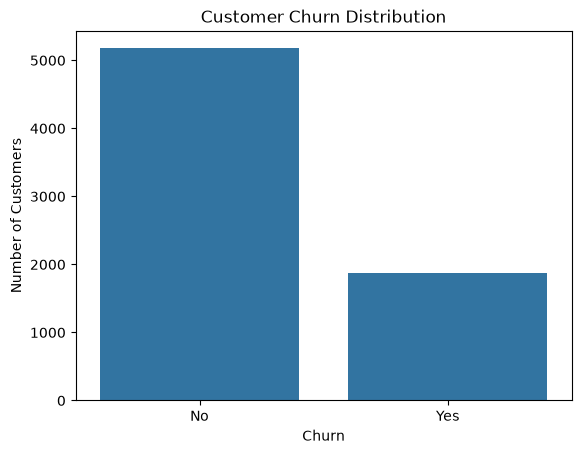

In [6]:
sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Churn by Contract Type

In [7]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


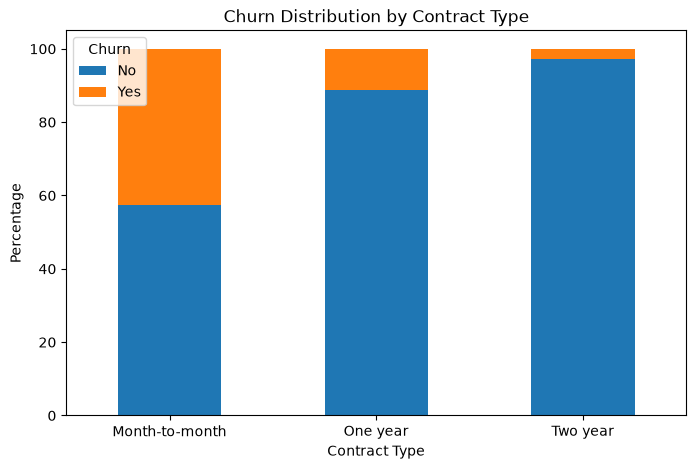

In [11]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.legend(title="Churn")
plt.show()

Churn by Tenure

In [12]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [13]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [14]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64

In [15]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn.round(2))

Churn            No    Yes
TenureGroup               
0-12 Months   52.56  47.44
13-24 Months  71.29  28.71
25-48 Months  79.61  20.39
49-72 Months  90.49   9.51


Visualize tenure vs churn

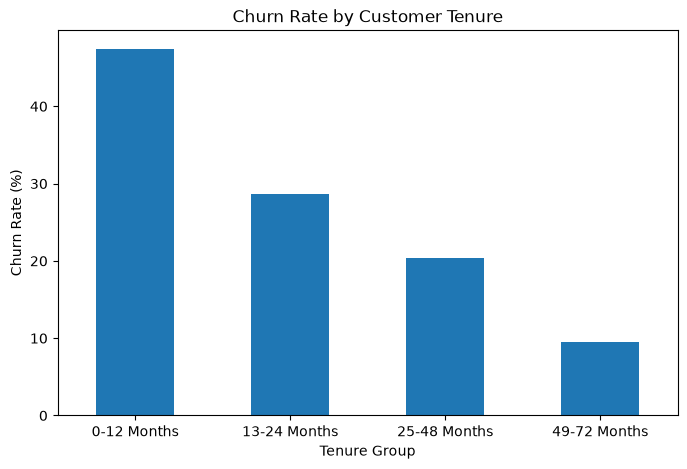

In [17]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Monthly Charges vs Churn

In [18]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


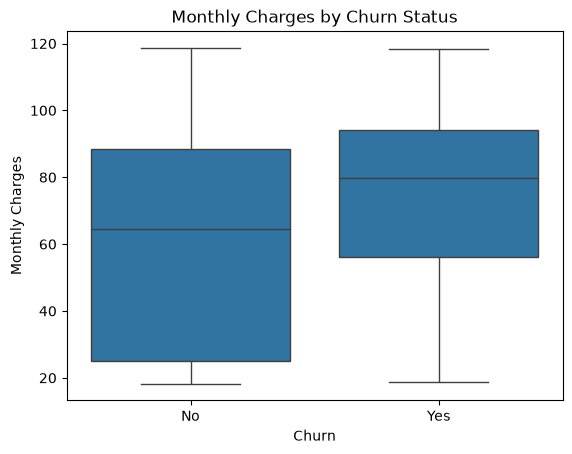

In [19]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Total Charges vs Churn

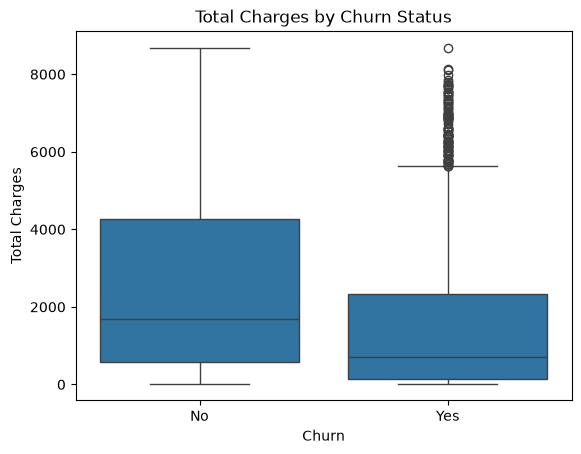

In [20]:
sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

Churn by internet service

In [21]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


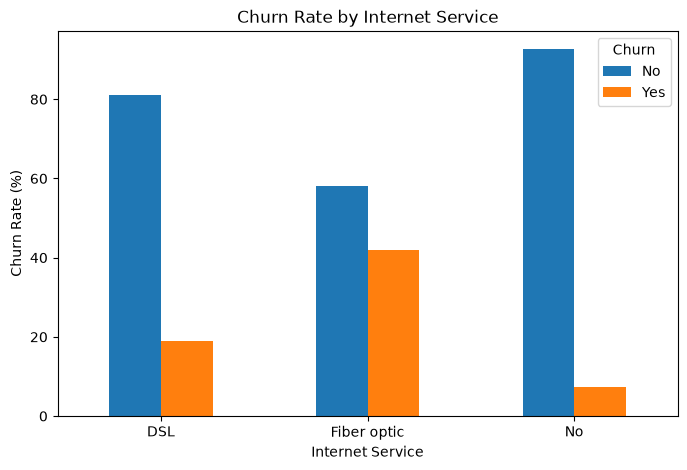

In [23]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Churn by payment method

In [24]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


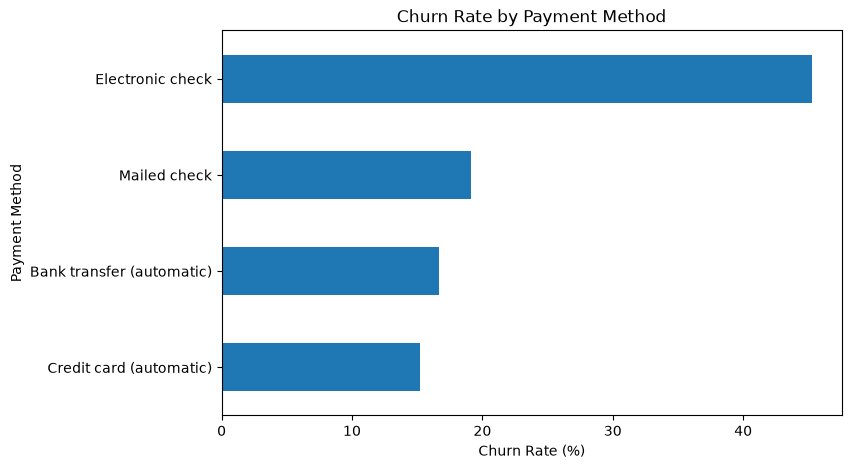

In [25]:
payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

Churn by senior citizen

In [29]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn.round(2))

Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


In [30]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

In [31]:
senior_churn = pd.crosstab(
    df["SeniorCitizenLabel"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn.round(2))

Churn                  No    Yes
SeniorCitizenLabel              
Non-Senior          76.39  23.61
Senior              58.32  41.68


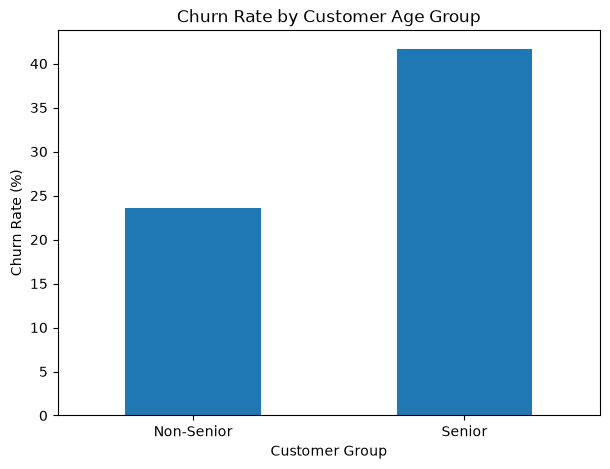

In [32]:
senior_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Customer Age Group")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Churn by partner

In [33]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn.round(2))

Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


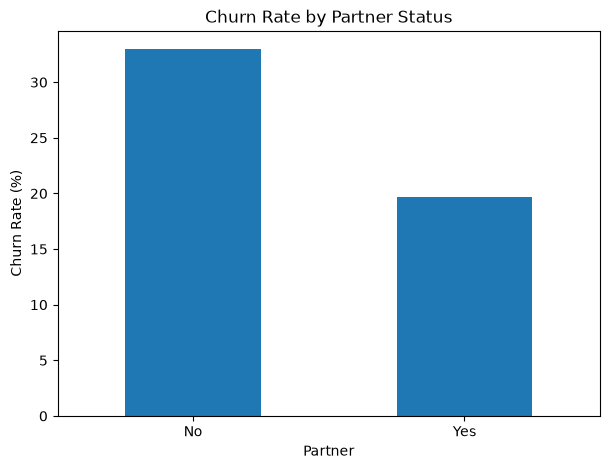

In [34]:
partner_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

Create a coorelation matrix

In [35]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_cols].corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000


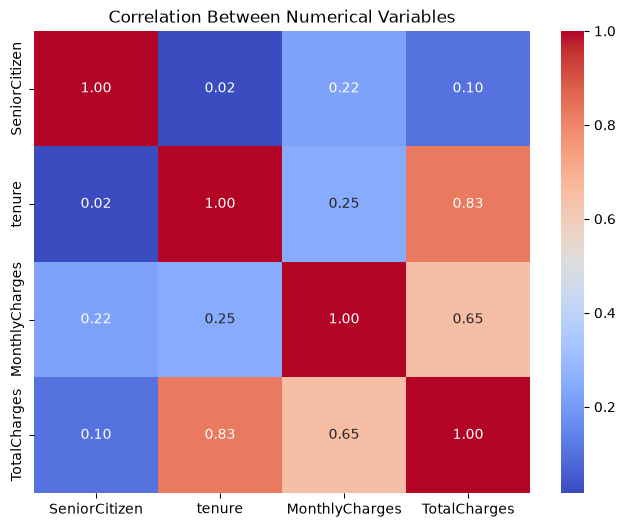

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

Business summary

In [37]:
summary = df.groupby("Contract").agg(
    Customers=("customerID", "count"),
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgTotalCharges=("TotalCharges", "mean"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
)

summary = summary.round(2)

summary

,Customers,AvgTenure,AvgMonthlyCharges,AvgTotalCharges,ChurnRate
Contract,,,,,
Month-to-month,3875,18.04,66.40,1369.25,42.71
One year,1473,42.04,65.05,3033.57,11.27
Two year,1695,56.74,60.77,3715.18,2.83


In [38]:
high_risk_segment = df[
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["MonthlyCharges"] > df["MonthlyCharges"].median())
]

print(high_risk_segment.shape)

(812, 23)


In [39]:
high_risk_churn = (
    high_risk_segment["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(high_risk_churn)

Churn
Yes    69.95
No     30.05
Name: proportion, dtype: float64


In [40]:
df.to_csv(
    "../data/processed/customers_eda.csv",
    index=False
)